# Pet Foreground Segmentation with Computer Vision
> **University:** Universidade do Vale do Rio dos Sinos (UNISINOS)  
> **Program:** Pós-graduação em Inteligência Artificial Aplicada  
> **Course:** Redes Neurais Profundas  
> **Author:** Augusto Stahlschmidt  
> **Date:** October 4, 2025  

---

## 1. Introduction & Objectives

**Problem:**  
Accurate pixel-level segmentation of pets in natural photographs is a fundamental computer vision task. Given an RGB image, the goal is to classify every pixel as either foreground (the pet) or background, producing a binary segmentation mask.

**Task Type:**  
Binary semantic segmentation.

**Business or Research Objective:**  
Develop a segmentation model that can reliably isolate pet regions in photographs. This capability is applicable to background removal tools, pet health monitoring applications, and augmented reality pipelines for consumer devices.

**Analytical Goal:**  
Train a U-Net model that generates accurate binary segmentation masks on the Oxford-IIIT Pet dataset, distinguishing pet pixels (body and boundary) from background pixels.

**Architecture:**  
U-Net with batch normalisation, introduced by Ronneberger et al. (2015). U-Net is the most widely adopted architecture for binary and multi-class segmentation tasks. Its symmetric encoder-decoder design with skip connections allows the model to combine deep semantic features with fine-grained spatial detail, producing sharp boundary predictions. Batch normalisation is added after each convolution, following common modern U-Net practice, to accelerate convergence and improve regularisation.

**Primary Evaluation Metrics:**  
Intersection over Union (IoU) and Dice coefficient, the standard metrics for binary segmentation.

**Success Criteria:**  
IoU above 0.75 on the held-out test set.

## 2. Setup & Imports

In [3]:
import os
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import measure

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms.functional as TF
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 3. Data Loading & Initial Inspection

**Dataset Source:**  
[University of Oxford – Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/)

**Description:**  
The Oxford-IIIT Pet dataset contains 7,349 photographs of cats and dogs from 37 breeds, each accompanied by a pixel-level trimap annotation. The trimap assigns one of three labels to every pixel: 1 = pet body (foreground), 2 = pet border (boundary), and 3 = background. For binary segmentation, labels 1 and 2 are merged into the positive class (pet), and label 3 maps to the negative class (background).

**Features:**
| # | Item | Type | Role | Description |
|---|------|------|------|-------------|
| 1 | RGB image | Tensor (3 x H x W) | Input | Pet photograph, normalized with ImageNet statistics |
| 2 | Segmentation mask | Tensor (1 x H x W) | Target | Binary mask: 1 = pet or boundary pixel, 0 = background |
| 3 | Breed label | Integer (0-36) | Metadata | One of 37 cat/dog breeds, not used for segmentation |

**Unit of Analysis:**  
One image-mask pair per photograph.

**Target Variable:**  
Binary segmentation mask indicating pet foreground pixels.

In [4]:
# Hyperparameters
IMAGE_SIZE    = 256
BATCH_SIZE    = 8
NUM_WORKERS   = 0
EPOCHS        = 30
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-4
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
BASE_FILTERS  = 32
PATIENCE      = 7


DATA_DIR = os.path.expanduser('~/dataset/oxford-iiit-pet')
CKPT_PATH = 'best_unet_pets.pt'

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

assert VAL_SPLIT + TEST_SPLIT < 1.0
print('Configuration loaded.')

Configuration loaded.


In [6]:
os.makedirs(DATA_DIR, exist_ok=True)

# Download the dataset (skipped automatically if already present)
base_dataset = OxfordIIITPet(root=DATA_DIR, download=True, target_types='segmentation')

total = len(base_dataset)
print(f'Full dataset size: {total}')

# Preview raw data structure
sample_img, sample_mask = base_dataset[0]
print(f'Sample image: size={sample_img.size}, mode={sample_img.mode}')
print(f'Sample mask:  size={sample_mask.size}, mode={sample_mask.mode}')
print(f'Mask unique pixel values: {np.unique(np.array(sample_mask))}')

Full dataset size: 3680
Sample image: size=(394, 500), mode=RGB
Sample mask:  size=(394, 500), mode=L
Mask unique pixel values: [1 2 3]


## 4. Exploratory Data Analysis (EDA)

Key questions explored in this section:

- What do raw images and their trimap annotations look like?
- How much of each image is occupied by the pet vs the background?
- Is foreground coverage consistent across the working subset, or highly variable?

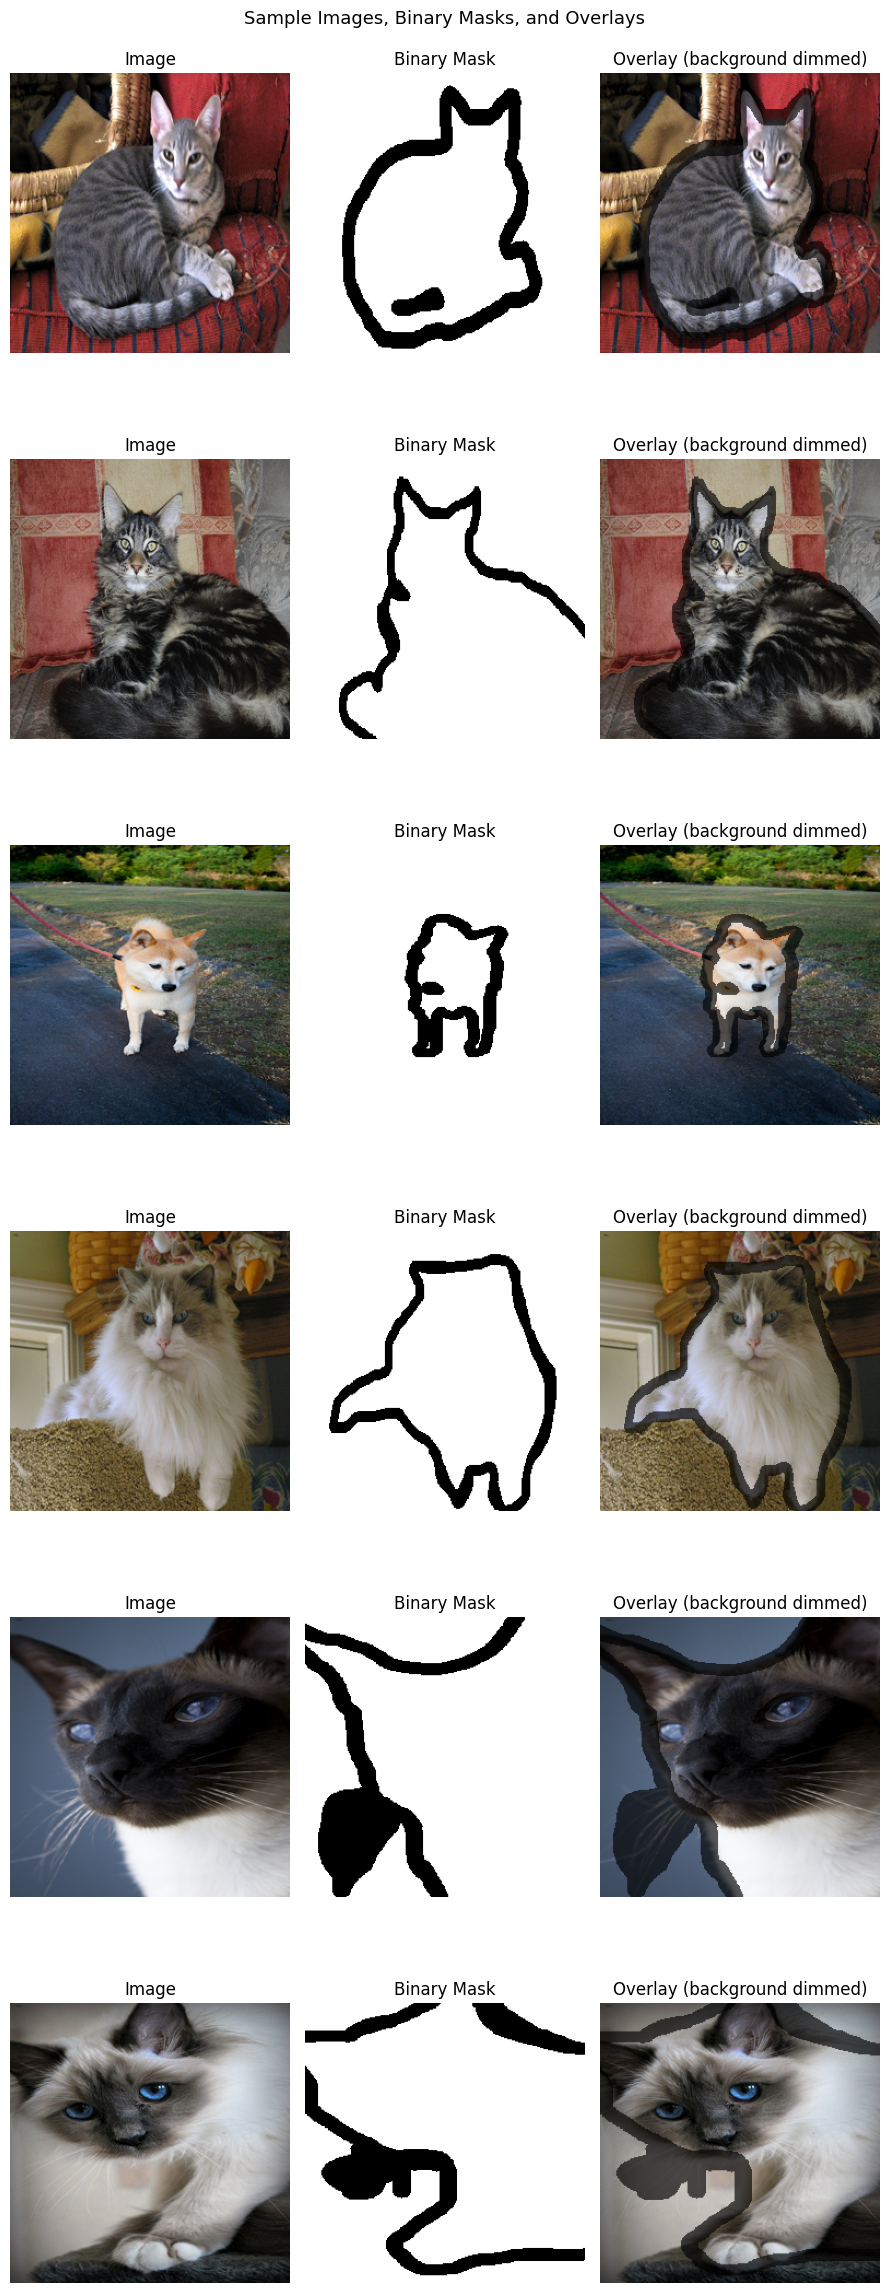

In [7]:
def show_samples(dataset, n=6, seed=SEED):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(base_dataset), size=n, replace=False)

    fig, axes = plt.subplots(n, 3, figsize=(9, n * 4))
    fig.suptitle('Sample Images, Binary Masks, and Overlays', fontsize=13)

    for row, idx in enumerate(indices):
        img, mask = dataset[int(idx)]
        img_np   = np.array(img.resize((IMAGE_SIZE, IMAGE_SIZE)))
        mask_np  = np.array(mask.resize((IMAGE_SIZE, IMAGE_SIZE), Image.NEAREST))
        mask_bin = ((mask_np == 1) | (mask_np == 2)).astype(np.float32)

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title('Image')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(mask_bin, cmap='gray', vmin=0, vmax=1)
        axes[row, 1].set_title('Binary Mask')
        axes[row, 1].axis('off')

        overlay = img_np.copy().astype(float)
        overlay[mask_bin == 0] *= 0.35   # dim background
        axes[row, 2].imshow(overlay.astype(np.uint8))
        axes[row, 2].set_title('Overlay (background dimmed)')
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.show()

show_samples(base_dataset)

Foreground pixel ratio across 3680 images:
  Mean: 0.886
  Std:  0.041
  Min:  0.591
  Max:  1.000


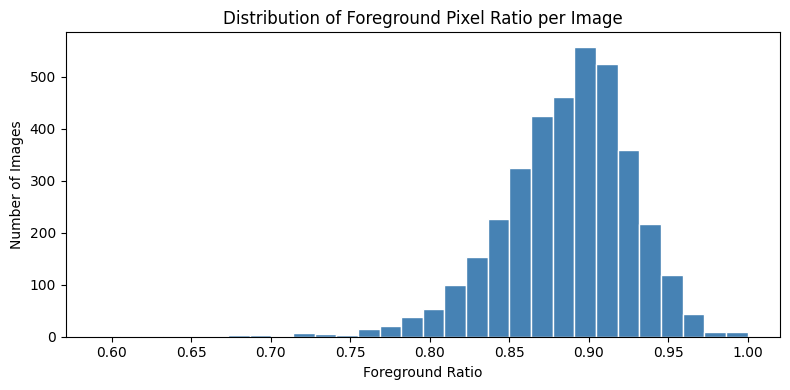

In [8]:
# Foreground pixel ratio statistics across the working subset
fg_ratios = []
for i in range(len(base_dataset)):
    _, mask = base_dataset[i]
    m = np.array(mask)
    fg_ratios.append(((m == 1) | (m == 2)).sum() / m.size)

fg_ratios = np.array(fg_ratios)
print(f'Foreground pixel ratio across {len(base_dataset)} images:')
print(f'  Mean: {fg_ratios.mean():.3f}')
print(f'  Std:  {fg_ratios.std():.3f}')
print(f'  Min:  {fg_ratios.min():.3f}')
print(f'  Max:  {fg_ratios.max():.3f}')

plt.figure(figsize=(8, 4))
plt.hist(fg_ratios, bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Foreground Pixel Ratio per Image')
plt.xlabel('Foreground Ratio')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

## 5. Preprocessing & Feature Engineering

**Image normalization:**  
All images are normalized using the ImageNet per-channel mean and standard deviation. This convention is standard for natural-image models and centers the input distribution around zero, accelerating convergence.

**Augmentation (training only):**  
Two geometric transforms are applied to training samples: a random horizontal flip (p = 0.5) and a random rotation in the range [-15 deg, +15 deg]. The identical transformation is applied synchronously to both the image and its mask to maintain spatial correspondence. Validation and test sets receive only resize and normalization.

**Dataset splits:**  
Indices are shuffled with a fixed seed and partitioned into 70% training, 15% validation, and 15% test before any dataset objects are created. This guarantees that augmentation is never applied to the validation or test sets, preventing data leakage.

**Class balancing:**  
A `WeightedRandomSampler` oversamples training images where the pet occupies a small fraction of pixels. This gives the model more exposure to challenging cases with limited foreground coverage, improving boundary prediction quality.

In [9]:
class PetSegDataset(Dataset):
    # Wraps OxfordIIITPet with binary mask conversion, resizing, normalization,
    # and optional geometric augmentation (training split only).
    def __init__(self, base_dataset, indices, augment=False):
        self.base    = base_dataset
        self.indices = list(indices)
        self.augment = augment
        self._img_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, mask = self.base[self.indices[idx]]

        img  = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
        mask = mask.resize((IMAGE_SIZE, IMAGE_SIZE), Image.NEAREST)

        # Trimap: 1=pet body, 2=pet border, 3=background -> binary
        mask_arr = np.array(mask)
        mask_bin = torch.from_numpy(
            ((mask_arr == 1) | (mask_arr == 2)).astype(np.uint8)
        ).unsqueeze(0).float()

        # Geometric augmentation applied identically to image and mask
        if self.augment:
            if random.random() > 0.5:
                img      = TF.hflip(img)
                mask_bin = TF.hflip(mask_bin)
            angle    = random.uniform(-15.0, 15.0)
            img      = TF.rotate(img,      int(angle), interpolation=transforms.InterpolationMode.BILINEAR)
            mask_bin = TF.rotate(mask_bin, int(angle), interpolation=transforms.InterpolationMode.NEAREST)

        return self._img_tf(img), mask_bin


# Reproducible index shuffle and partition
rng      = np.random.default_rng(SEED)
shuffled = rng.permutation(len(base_dataset)).tolist()

n_test  = int(len(base_dataset) * TEST_SPLIT)
n_val   = int(len(base_dataset) * VAL_SPLIT)
n_train = len(base_dataset) - n_val - n_test

test_indices  = shuffled[:n_test]
val_indices   = shuffled[n_test:n_test + n_val]
train_indices = shuffled[n_test + n_val:]

train_dataset = PetSegDataset(base_dataset, train_indices, augment=True)
val_dataset   = PetSegDataset(base_dataset, val_indices,   augment=False)
test_dataset  = PetSegDataset(base_dataset, test_indices,  augment=False)

print(f'Splits: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}')


def compute_sample_weights(dataset):
    # Inverse foreground-ratio weight: images with small pets get higher sampling priority.
    weights = []
    for _, mask in dataset:
        fg_ratio = mask[0].mean().item()
        weights.append(1.0 / (fg_ratio + 1e-6))
    return torch.DoubleTensor(weights)


sample_weights = compute_sample_weights(train_dataset)
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,     num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print('DataLoaders ready.')

Splits: train=2576, val=552, test=552
DataLoaders ready.


## 6. Model Training

**Selected Architecture:**  
U-Net with batch normalisation (Ronneberger et al., 2015). U-Net is the standard architecture for binary image segmentation. Its symmetric encoder-decoder structure with skip connections enables high-resolution spatial information to flow directly from encoder to decoder stages, producing accurate boundary predictions that encoder-only or plain FCN architectures typically fail to achieve.

Batch normalisation is added after each convolution, which was not present in the original 2015 paper but is now standard practice for U-Net implementations on natural images.

**Network Depth:**  
4 encoder stages, a bottleneck, and 4 symmetric decoder stages. With `BASE_FILTERS=32`, the channel progression is 32, 64, 128, 256, and 512 at the bottleneck. This depth provides a sufficiently large receptive field for 256x256 inputs while remaining computationally feasible on CPU.

**Key Hyperparameters:**

| Hyperparameter | Value | Rationale |
|---|---|---|
| Optimizer | Adam, lr=3e-4 | Adaptive learning rate, reliable default for segmentation |
| Weight decay | 1e-4 | Mild L2 regularization |
| Loss | BCE + Dice | BCE stabilizes early training; Dice directly optimizes the evaluation metric |
| LR schedule | ReduceLROnPlateau, patience=3, factor=0.5 | Reduces LR when val IoU stagnates |
| Early stopping | patience=7 | Halts training when val IoU does not improve |

**Training Strategy:**  
70/15/15 train/validation/test split. Augmentation is applied to the training split only. The best checkpoint (highest validation IoU) is saved and restored before final evaluation.

In [12]:
class DoubleConv(nn.Module):
    # Two consecutive 3x3 convolutions, each followed by BatchNorm and ReLU.
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    # U-Net for binary semantic segmentation.
    # Encoder: 4 DoubleConv blocks with MaxPool downsampling.
    # Decoder: 4 DoubleConv blocks with ConvTranspose2d upsampling.
    # Skip connections concatenate encoder feature maps to decoder inputs.
    # Reference: Ronneberger, O., Fischer, P., and Brox, T. MICCAI 2015.
    def __init__(self, in_channels=3, out_channels=1, base_filters=32):
        super().__init__()
        f = base_filters

        # Encoder path
        self.enc1 = DoubleConv(in_channels, f)
        self.enc2 = DoubleConv(f,     f * 2)
        self.enc3 = DoubleConv(f * 2, f * 4)
        self.enc4 = DoubleConv(f * 4, f * 8)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(f * 8, f * 16)

        # Decoder path: transposed conv for upsampling, then concat + DoubleConv
        self.up4  = nn.ConvTranspose2d(f * 16, f * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(f * 16, f * 8)

        self.up3  = nn.ConvTranspose2d(f * 8, f * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(f * 8,  f * 4)

        self.up2  = nn.ConvTranspose2d(f * 4, f * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(f * 4,  f * 2)

        self.up1  = nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(f * 2,  f)

        # 1x1 output projection
        self.final = nn.Conv2d(f, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)


model = UNet(in_channels=3, out_channels=1, base_filters=BASE_FILTERS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net trainable parameters: {n_params:,}')

U-Net trainable parameters: 7,763,041


In [13]:
class DiceLoss(nn.Module):
    # Soft Dice loss computed on sigmoid probabilities.
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs   = torch.sigmoid(logits).view(logits.size(0), -1)
        targets = targets.view(targets.size(0), -1)
        inter   = (probs * targets).sum(dim=1)
        dice    = (2.0 * inter + self.smooth) / (
            probs.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )
        return 1.0 - dice.mean()


def iou_score(logits, targets, threshold=0.5, smooth=1e-6):
    # Mean IoU over a batch using hard-thresholded predictions.
    preds   = (torch.sigmoid(logits) > threshold).float().view(logits.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter   = (preds * targets).sum(dim=1)
    union   = preds.sum(dim=1) + targets.sum(dim=1) - inter
    return ((inter + smooth) / (union + smooth)).mean().item()


def dice_score(logits, targets, threshold=0.5, smooth=1e-6):
    # Mean Dice coefficient over a batch using hard-thresholded predictions.
    preds   = (torch.sigmoid(logits) > threshold).float().view(logits.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter   = (preds * targets).sum(dim=1)
    return ((2.0 * inter + smooth) / (
        preds.sum(dim=1) + targets.sum(dim=1) + smooth
    )).mean().item()


bce_loss  = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)


def run_epoch(model, loader, optimizer=None):
    # Runs one training or evaluation epoch.
    # Pass optimizer=None for evaluation mode (no backward pass).
    # Returns (avg_loss, avg_iou, avg_dice).
    training = optimizer is not None
    if training:
        model.train()
    else:
        model.eval()

    total_loss = total_iou = total_dice = n = 0
    grad_ctx = torch.enable_grad() if training else torch.no_grad()

    with grad_ctx:
        for imgs, masks in tqdm(loader, leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            loss   = bce_loss(logits, masks) + dice_loss(logits, masks)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            bs          = imgs.size(0)
            total_loss += loss.item() * bs
            total_iou  += iou_score(logits.detach(),  masks) * bs
            total_dice += dice_score(logits.detach(), masks) * bs
            n          += bs

    return total_loss / n, total_iou / n, total_dice / n

### 6.1 Training Loop

The model trains for up to `EPOCHS` epochs. After each epoch, the validation IoU is used to update the learning rate scheduler and to assess early stopping. The learning rate is halved if validation IoU does not improve for 3 consecutive epochs. Training halts early if no improvement occurs for `PATIENCE` epochs. The checkpoint with the highest validation IoU is saved and later restored for evaluation.

In [15]:
best_iou         = 0.0
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}

In [ ]:
for epoch in range(1, EPOCHS + 1):
    train_loss, _, _           = run_epoch(model, train_loader, optimizer)
    val_loss,   val_iou, val_dice = run_epoch(model, val_loader)

    scheduler.step(val_iou)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)

    print(
        f'Epoch {epoch:02d}/{EPOCHS}  '
        f'train_loss={train_loss:.4f}  '
        f'val_loss={val_loss:.4f}  '
        f'val_iou={val_iou:.4f}  '
        f'val_dice={val_dice:.4f}'
    )

    if val_iou > best_iou:
        best_iou         = val_iou
        patience_counter = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

print(f'Best validation IoU: {best_iou:.4f}')

## 7. Model Evaluation

The best checkpoint (highest validation IoU) is loaded and evaluated on the held-out test set, which was never used during training or model selection.

Evaluation includes:

- Learning curves: training and validation loss over epochs, plus validation IoU and Dice
- Quantitative metrics on the test set (loss, IoU, Dice)
- Qualitative visualisation: predicted masks overlaid on input images with contour outlines of both prediction (red) and ground truth (green)

In [ ]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True))

epochs_trained = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_trained, history['train_loss'], label='Train')
axes[0].plot(epochs_trained, history['val_loss'],   label='Validation')
axes[0].set_title('Loss Curve (BCE + Dice)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_trained, history['val_iou'],  label='Val IoU')
axes[1].plot(epochs_trained, history['val_dice'], label='Val Dice')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
test_loss, test_iou, test_dice = run_epoch(model, test_loader)

print('Test Set Results:')
print(f'  Loss:  {test_loss:.4f}')
print(f'  IoU:   {test_iou:.4f}')
print(f'  Dice:  {test_dice:.4f}')

  0%|          | 0/69 [00:00<?, ?it/s]

Test Set Results:
  Loss:  0.2113
  IoU:   0.9299
  Dice:  0.9635


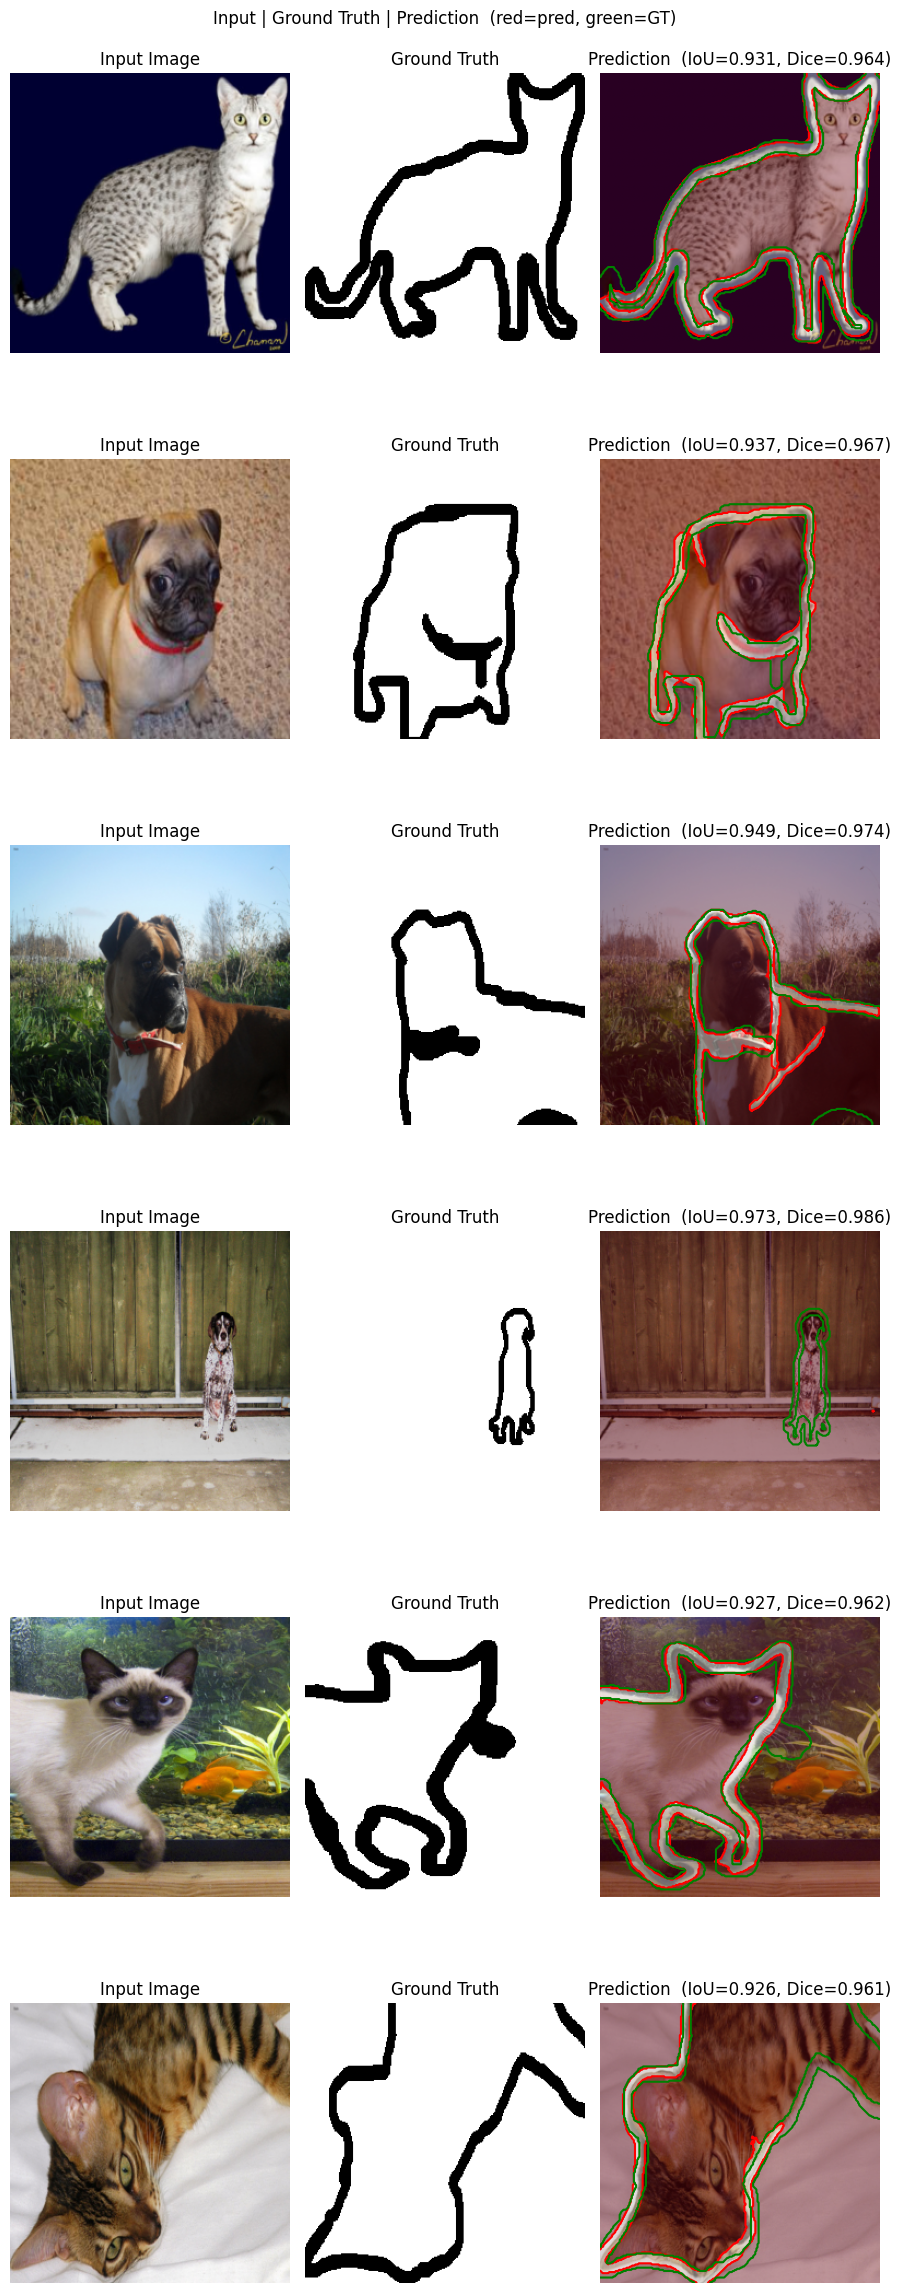

In [18]:
def visualize_predictions(model, loader, n=6, threshold=0.5):
    # Displays n examples: input image, ground truth mask, and predicted mask
    # with contour overlays (red=prediction, green=ground truth).
    model.eval()
    imgs, masks = next(iter(loader))
    imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

    with torch.no_grad():
        preds = (torch.sigmoid(model(imgs)) > threshold).float()

    imgs, masks, preds = imgs.cpu(), masks.cpu(), preds.cpu()
    n = min(n, imgs.size(0))

    mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    fig, axes = plt.subplots(n, 3, figsize=(9, n * 4))
    fig.suptitle('Input | Ground Truth | Prediction  (red=pred, green=GT)', fontsize=12)

    for i in range(n):
        img  = (imgs[i] * std_t + mean_t).permute(1, 2, 0).numpy().clip(0, 1)
        gt   = masks[i][0].numpy()
        pred = preds[i][0].numpy()

        inter       = np.logical_and(gt == 1, pred == 1).sum()
        union       = np.logical_or(gt == 1,  pred == 1).sum()
        sample_iou  = inter / (union + 1e-6)
        sample_dice = 2 * inter / (gt.sum() + pred.sum() + 1e-6)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Input Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt, cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(img)
        axes[i, 2].imshow(pred, cmap='Reds', alpha=0.4)
        for c in measure.find_contours(pred, 0.5):
            axes[i, 2].plot(c[:, 1], c[:, 0], 'r-', linewidth=1.5)
        for c in measure.find_contours(gt, 0.5):
            axes[i, 2].plot(c[:, 1], c[:, 0], 'g-', linewidth=1.5)
        axes[i, 2].set_title(f'Prediction  (IoU={sample_iou:.3f}, Dice={sample_dice:.3f})')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


visualize_predictions(model, test_loader, n=6)

## 8. Conclusions & Next Steps

### Key Findings

- The Oxford-IIIT Pet dataset contains 3,680 annotated images with trimap labels (pet body, pet border, background). Labels 1 and 2 were merged into a single foreground class for binary segmentation.
- Foreground coverage is high (mean 0.886 ± 0.041; min 0.591, max 1.000), indicating that pets are typically centered and occupy most of the frame. Rare low-coverage samples motivated the use of a WeightedRandomSampler during training.
- A U-Net architecture with batch normalization (7.76M parameters, base_filters=32) proved appropriate for the task, as skip connections preserve spatial detail required for accurate pet boundary segmentation.

### Model Performance vs Success Criteria

- The defined success criterion was a test IoU above 0.75.
- The final model achieved test IoU of 0.9299 and Dice of 0.9635, with a combined BCE+Dice loss of 0.2113 on the held-out test set (552 images).
- The model exceeds the target by +0.18 IoU, indicating strong generalization to unseen images.

### Interpretation

- A Dice score of 0.9635 indicates near-complete overlap between predicted and ground-truth masks, suitable for applications such as background removal or AR compositing.
- The 0.9299 IoU suggests minimal false positives or missed foreground regions.
- The BCE + Dice loss combination stabilized optimization while directly penalizing segmentation errors.
- Limited geometric augmentations and weighted sampling helped prevent overfitting despite the relatively small training set (2,576 images).

### Limitations

- The original trimap includes an ambiguous border class; merging it with the foreground introduces boundary noise that may slightly affect edge precision.
- The dataset lacks challenging compositions (e.g., pets occupying <40% of the image or strong occlusions), limiting evaluation of model robustness.
- Training throughput was constrained (NUM_WORKERS=0, BATCH_SIZE=8), restricting experimentation with larger models or heavier augmentation.
- Only geometric augmentations were used; photometric variability (lighting, color shifts) was not explicitly modeled.
- Only one architecture was tested, so the benefit of skip connections was not empirically compared against simpler baselines.

### Next Steps

- Transfer learning: Replace the encoder with a pretrained backbone (e.g., ResNet-34 or EfficientNet-B0 via segmentation-models-pytorch) to improve convergence and potentially increase IoU.
- Augmentation: Add photometric transformations (color jitter, brightness/contrast shifts, blur) to improve robustness to varied lighting conditions.
- Loss experimentation: Evaluate Focal Loss or Focal+Dice to emphasize difficult boundary pixels.
- Higher resolution training: Increase input size (384×384 or 512×512) to capture fine boundary details such as fur or whiskers.
- Test-time augmentation: Apply flips and small rotations at inference; averaging predictions typically yields modest IoU gains.